# <center>Smart Complaint Categorization for Government Portals</center>

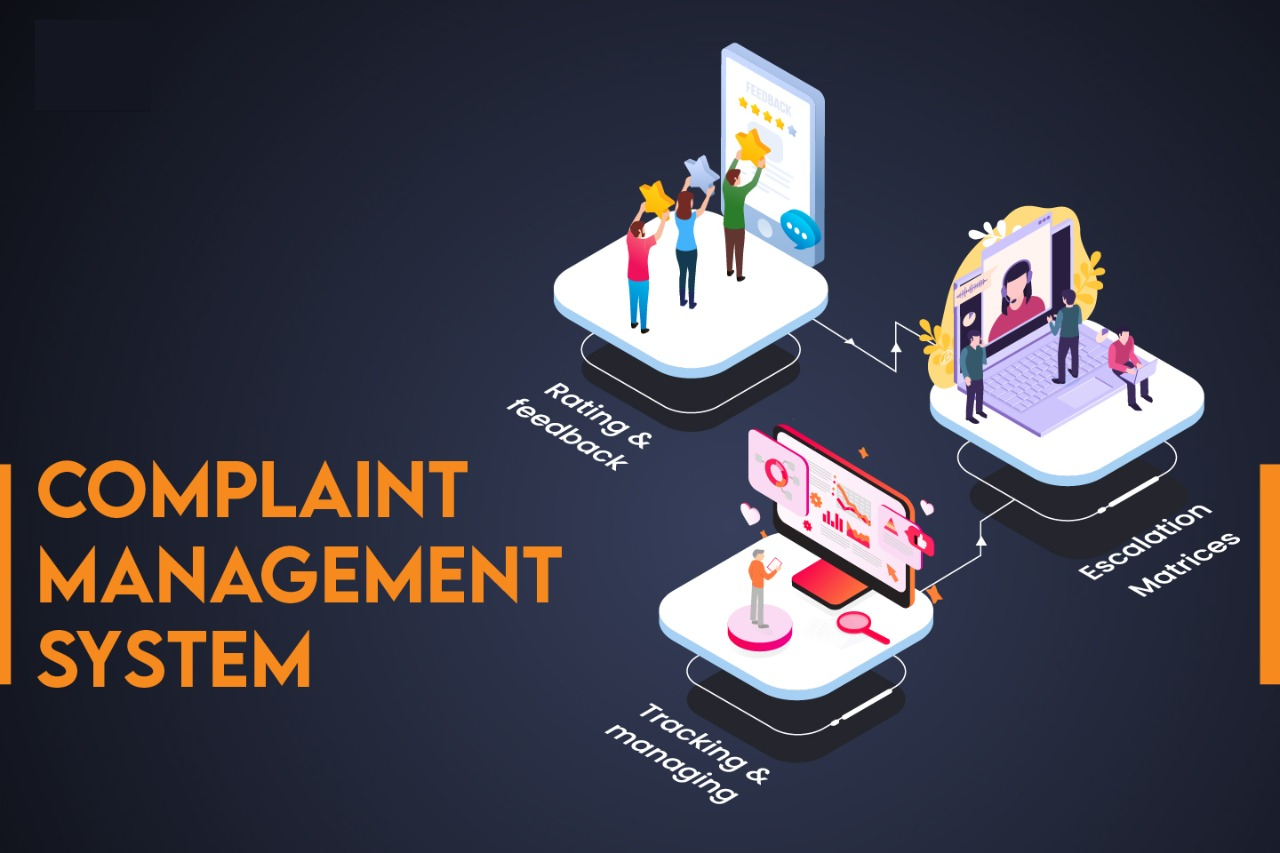

# 🏆Abstract:
* This project uses NLP to automatically classify citizen complaints into predefined departments such as water, roads, electricity, or sanitation. Text preprocessing and feature extraction help identify key issue patterns within large volumes of complaints. ML models categorize complaints with high accuracy, enabling faster redirection to the correct authority. The system reduces manual workload and improves government response time. It enhances public service efficiency by ensuring quick and accurate issue resolution.

# 📘Introduction:

* The rapid growth of urban populations has led to an increase in citizen complaints related to civic issues such as water supply, road conditions, electricity, and sanitation. Managing these complaints manually is time-consuming, inefficient, and often leads to delays in resolving issues. Government portals receive a large volume of complaints daily, making it difficult to categorize and route them to the appropriate departments quickly.

* This project, Smart Complaint Categorization for Government Portals, uses Natural Language Processing (NLP) and Machine Learning techniques to automatically classify citizen complaints into predefined categories. By analyzing textual complaint data, the system identifies patterns and assigns each complaint to the relevant department, thereby improving efficiency and reducing manual effort. The solution aims to enhance public service delivery and ensure faster grievance redressal.

# 🎯Objectives:

* To develop an NLP-based system for automatic classification of citizen complaints.
* To preprocess and clean textual data for better model performance.
* To implement feature extraction techniques such as TF-IDF.
* To train multiple machine learning models for classification.
* To compare different models and select the best-performing one.
* To deploy the model using a simple user interface (Streamlit).
* To visualize complaint data using dashboards (Power BI).
* To improve government response time and efficiency.

# 🏁Project Outcome:

* A fully functional machine learning model capable of classifying complaints into categories like Water, Roads, Electricity, and Sanitation.
* Achieved high accuracy using advanced models such as XGBoost.
* Developed an interactive web application using Streamlit for real-time complaint classification.
* Created a data visualization dashboard using Microsoft Power BI to analyze complaint trends.
* Reduced manual workload and improved the speed of complaint routing.
* Built a scalable solution that can handle large volumes of complaint data.

# 🚀Future Scope:

* Integrating real-time data from government portals for live complaint analysis.
* Expanding categories to include more departments (health, transport, education, etc.).
* Implementing deep learning models (like LSTM or BERT) for better accuracy.
* Adding multilingual support to handle complaints in regional languages.
* Developing a mobile application for easier accessibility.
* Integrating chatbot systems for automatic complaint registration and response.
* Using sentiment analysis to prioritize urgent complaints.
* Deploying the system on cloud platforms for scalability and real-time usage.

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The libraries NumPy, Pandas, Matplotlib, and Seaborn are essential tools in data science. NumPy is used for numerical computations, Pandas for data manipulation and analysis, while Matplotlib and Seaborn help in data visualization. Together, they enable efficient data processing, analysis, and insightful graphical representation.

# Load Dataset

In [2]:
df = pd.read_csv("Smart_Complaint_Categorization_dataset.csv")

This code uses the Pandas library to load the dataset Smart_Complaint_Categorization_dataset.csv into a DataFrame (df), which allows easy data manipulation, analysis, and visualization.

# Data Gathering

In [3]:
df.head()

,complaint_id,complaint_text,category,city,date_submitted,status,priority,complaint_length,word_count,Water,Roads,Electricity,Sanitation
0,1,Transformer malfunction causing electricity di...,Electricity,Mumbai,2024-12-16,Resolved,Medium,54,5,0,0,1,0
1,2,Frequent power cuts occurring in our area ever...,Electricity,Mumbai,2024-11-28,Pending,High,53,9,0,0,1,0
2,3,Drainage water is mixing with drinking water s...,Water,Mumbai,2024-01-31,Resolved,Medium,51,8,1,0,0,0
3,4,There is continuous water leakage from the mai...,Water,Rajkot,2024-10-21,In Progress,High,70,12,1,0,0,0
4,5,Voltage fluctuations damaging electrical appli...,Electricity,Delhi,2024-11-02,In Progress,Low,51,5,0,0,1,0


The df.head() function displays the first 5 rows of the dataset, allowing a quick preview of the data structure, columns, and values.

In [4]:
df.tail()

,complaint_id,complaint_text,category,city,date_submitted,status,priority,complaint_length,word_count,Water,Roads,Electricity,Sanitation
1995,1996,Overflowing dustbins causing unhygienic condit...,Sanitation,Mumbai,2024-04-14,Pending,High,50,5,0,0,0,1
1996,1997,Residents are facing severe water shortage for...,Water,Mumbai,2024-11-07,In Progress,Low,66,11,1,0,0,0
1997,1998,Frequent power cuts occurring in our area ever...,Electricity,Rajkot,2024-08-30,Open,Low,53,9,0,0,1,0
1998,1999,There is continuous water leakage from the mai...,Water,Surat,2024-08-02,In Progress,Medium,70,12,1,0,0,0
1999,2000,Frequent power cuts occurring in our area ever...,Electricity,Delhi,2024-12-10,In Progress,High,53,9,0,0,1,0


The df.tail() function displays the last 5 rows of the dataset, helping to view the ending entries and verify data completeness.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   complaint_id      2000 non-null   int64 
 1   complaint_text    2000 non-null   object
 2   category          2000 non-null   object
 3   city              2000 non-null   object
 4   date_submitted    2000 non-null   object
 5   status            2000 non-null   object
 6   priority          2000 non-null   object
 7   complaint_length  2000 non-null   int64 
 8   word_count        2000 non-null   int64 
 9   Water             2000 non-null   int64 
 10  Roads             2000 non-null   int64 
 11  Electricity       2000 non-null   int64 
 12  Sanitation        2000 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 203.3+ KB


The df.info() function provides a summary of the dataset, including column names, data types, non-null values, and memory usage.

In [6]:
df.describe()

,complaint_id,complaint_length,word_count,Water,Roads,Electricity,Sanitation
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.0000,2000.000000
mean,1000.500000,51.147500,7.510500,0.25500,0.249500,0.2415,0.254000
std,577.494589,8.182862,2.076065,0.43597,0.432832,0.4281,0.435406
min,1.000000,37.000000,5.000000,0.00000,0.000000,0.0000,0.000000
25%,500.750000,47.000000,5.750000,0.00000,0.000000,0.0000,0.000000
50%,1000.500000,51.000000,8.000000,0.00000,0.000000,0.0000,0.000000
75%,1500.250000,53.000000,8.000000,1.00000,0.000000,0.0000,1.000000
max,2000.000000,70.000000,12.000000,1.00000,1.000000,1.0000,1.000000


The df.describe() function generates statistical summaries of numerical columns, including count, mean, standard deviation, minimum, and maximum values.

In [7]:
df.shape

(2000, 13)

The df.shape attribute returns the number of rows and columns in the dataset, helping to understand its size.

In [8]:
df.columns.tolist()

['complaint_id',
 'complaint_text',
 'category',
 'city',
 'date_submitted',
 'status',
 'priority',
 'complaint_length',
 'word_count',
 'Water',
 'Roads',
 'Electricity',
 'Sanitation']

The df.columns.tolist() function returns a list of all column names in the dataset, making it easy to view and access them.

# DATA CLEANING (Pandas + NumPy)

In [9]:
df = df[['complaint_id','complaint_text','category','city','date_submitted','status','priority','complaint_length','word_count','Water','Roads','Electricity','Sanitation']]
df.columns = ['complaint_id','complaint_text','category','city','date_submitted','status','priority','complaint_length','word_count','Water','Roads','Electricity','Sanitation']

This code selects specific relevant columns from the dataset and reassigns them to the DataFrame, ensuring proper structure and consistent column naming for further analysis.

In [10]:
df = df.dropna()

This code removes all rows with missing (null) values from the dataset, ensuring cleaner and more reliable data for analysis.

In [11]:
df = df.drop_duplicates(subset=['complaint_text'])

This code removes duplicate rows based on the complaint_text column, ensuring that each complaint is unique in the dataset.

In [12]:
df['category'] = df['category'].str.strip().str.lower()

This code cleans the category column by removing extra spaces and converting all text to lowercase, ensuring consistency in the data.

In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

This code standardizes column names by removing extra spaces, converting them to lowercase, and replacing spaces with underscores, making them consistent and easier to use.

In [14]:
if 'city' in df.columns:
    df['city'] = df['city'].str.strip().str.lower()

if 'status' in df.columns:
    df['status'] = df['status'].str.strip().str.lower()

if 'priority' in df.columns:
    df['priority'] = df['priority'].str.strip().str.lower()

This code checks if the columns city, status, and priority exist, and then cleans their values by removing extra spaces and converting them to lowercase, ensuring consistency across the dataset.

In [15]:
df = df.rename(columns={'complaint_text': 'complaints'})

This code renames the column complaint_text to complaints, making it simpler and more convenient for further analysis.

In [16]:
df.head()

,complaint_id,complaints,category,city,date_submitted,status,priority,complaint_length,word_count,water,roads,electricity,sanitation
0,1,Transformer malfunction causing electricity di...,electricity,mumbai,2024-12-16,resolved,medium,54,5,0,0,1,0
1,2,Frequent power cuts occurring in our area ever...,electricity,mumbai,2024-11-28,pending,high,53,9,0,0,1,0
2,3,Drainage water is mixing with drinking water s...,water,mumbai,2024-01-31,resolved,medium,51,8,1,0,0,0
3,4,There is continuous water leakage from the mai...,water,rajkot,2024-10-21,in progress,high,70,12,1,0,0,0
4,5,Voltage fluctuations damaging electrical appli...,electricity,delhi,2024-11-02,in progress,low,51,5,0,0,1,0


# EDA(Exploratory Data Analysis)

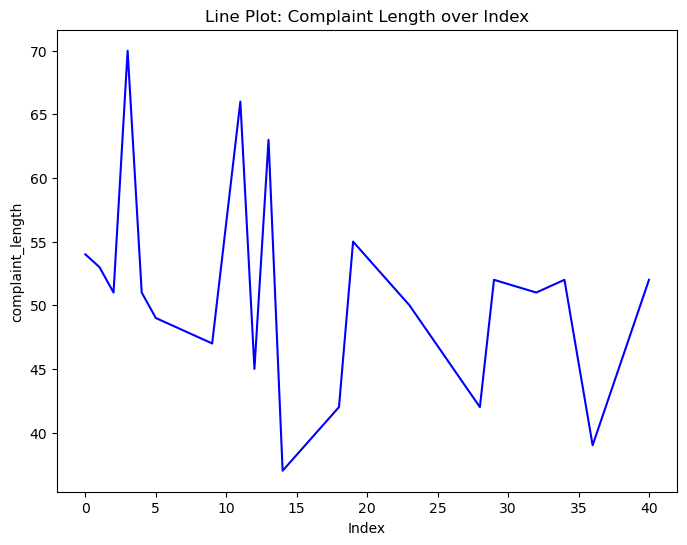

In [17]:
plt.figure(figsize=(8,6))
plt.plot(df.index, df['complaint_length'], color='blue')
plt.title("Line Plot: Complaint Length over Index")
plt.xlabel("Index")
plt.ylabel("complaint_length")
plt.show()

This line plot represents the variation in complaint length across the dataset index. Each point on the graph corresponds to the length of a complaint at a particular position in the dataset. By visualizing this, we can observe how complaint lengths fluctuate, identify any unusual spikes or drops, and understand whether the data is consistent or highly variable. This helps in gaining insights into the distribution and behavior of complaint text length, which is useful for further preprocessing and modeling.

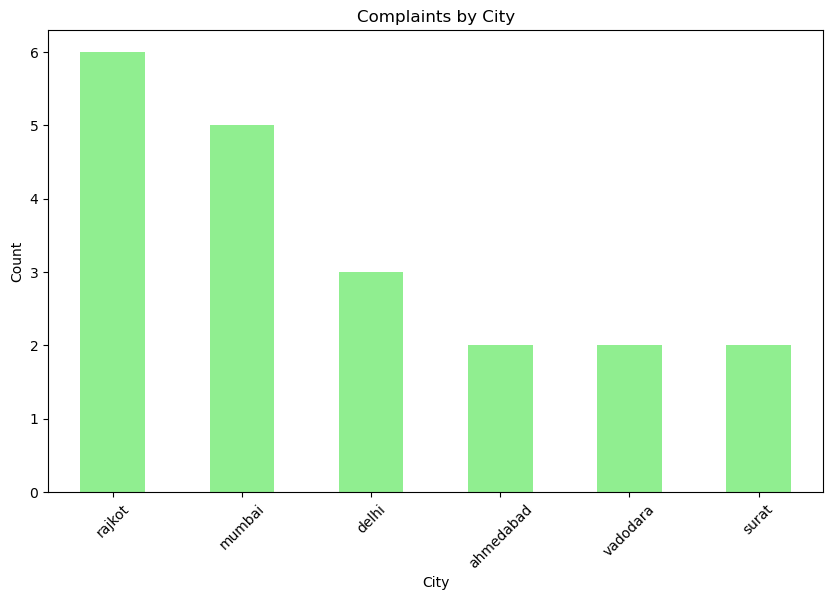

In [18]:
plt.figure(figsize=(10,6))
df['city'].value_counts().plot(kind='bar', color='lightgreen')
plt.title("Complaints by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

This bar chart visualizes the distribution of complaints across different cities. Each bar represents the total number of complaints received from a specific city, making it easy to compare complaint volumes between locations. By analyzing this chart, we can identify which cities have the highest and lowest number of complaints, helping to highlight regions with more issues or higher reporting activity. This insight is valuable for understanding geographical patterns in the data and can assist authorities in focusing resources and attention on areas with greater needs.

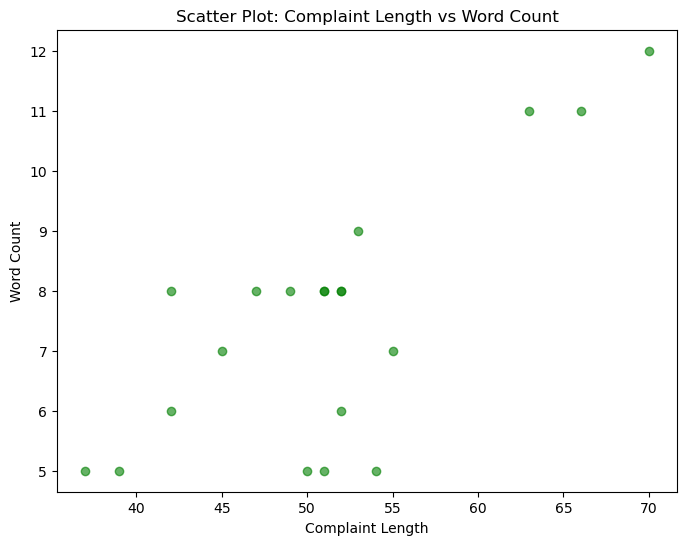

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(df['complaint_length'], df['word_count'], alpha=0.6, color='green')
plt.title("Scatter Plot: Complaint Length vs Word Count")
plt.xlabel("Complaint Length")
plt.ylabel("Word Count")
plt.show()

This scatter plot illustrates the relationship between complaint length and word count in the dataset. Each point represents a complaint, with its position indicating the length of the complaint and the number of words it contains. The plot helps in identifying patterns or correlations between these two variables, such as whether longer complaints generally contain more words. It also allows us to detect any outliers or unusual data points. This analysis is useful for understanding the structure of textual data and can support better preprocessing and feature engineering in later stages.

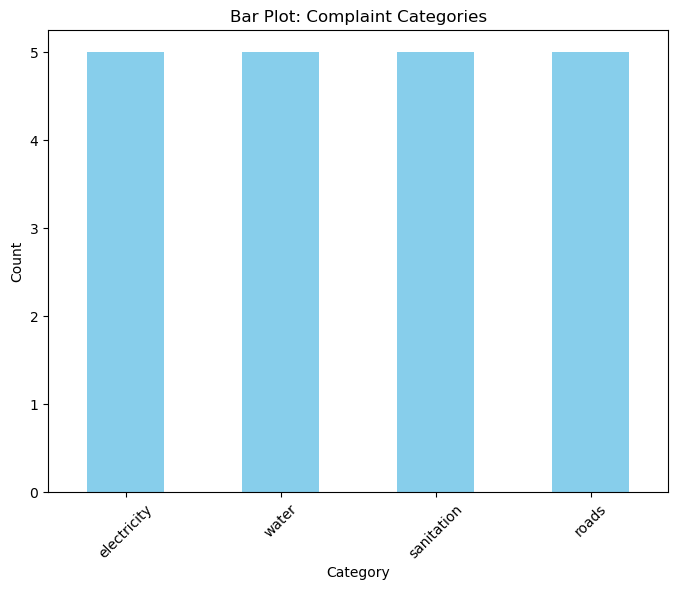

In [20]:
plt.figure(figsize=(8,6))
df['category'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Bar Plot: Complaint Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

This bar chart represents the distribution of complaints across different categories. Each bar shows the total number of complaints for a specific category, making it easy to compare how frequently each type of issue occurs. By analyzing this visualization, we can identify which categories have the highest number of complaints and which are less common. This helps in understanding the major areas of concern and supports better decision-making by highlighting where attention and resources are most needed.

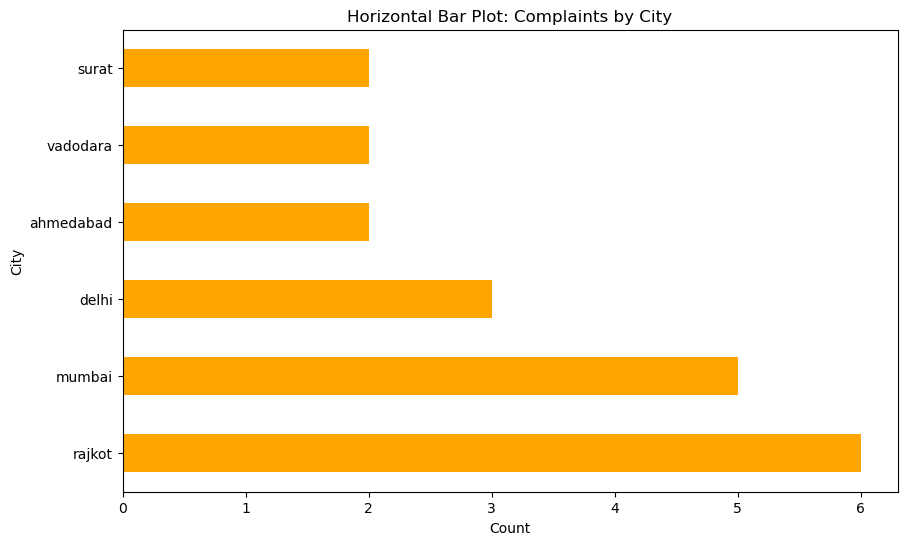

In [21]:
plt.figure(figsize=(10,6))
df['city'].value_counts().plot(kind='barh', color='orange')
plt.title("Horizontal Bar Plot: Complaints by City")
plt.xlabel("Count")
plt.ylabel("City")
plt.show()

The horizontal bar plot shows the distribution of complaints across different cities. Some cities have noticeably higher complaint counts, indicating areas with recurring issues or higher reporting activity. In contrast, cities with fewer complaints may reflect fewer problems or lower reporting. This visualization helps identify priority regions that may require attention and can guide resource allocation and policy decisions to improve services and citizen satisfaction.

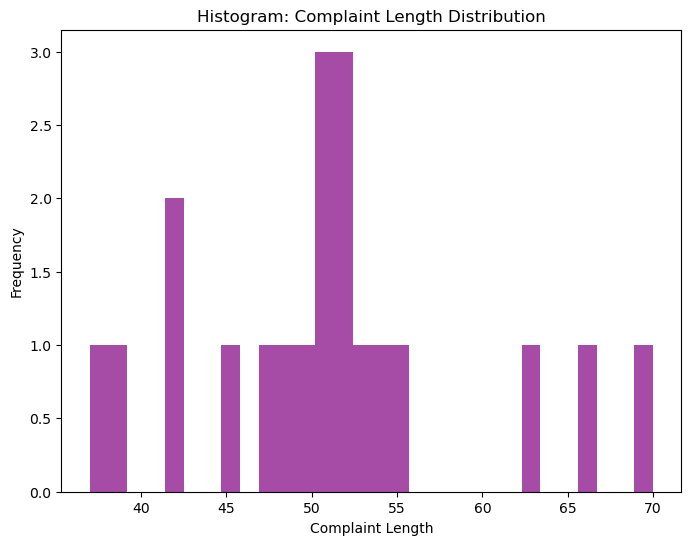

In [22]:
plt.figure(figsize=(8,6))
plt.hist(df['complaint_length'], bins=30, color='purple', alpha=0.7)
plt.title("Histogram: Complaint Length Distribution")
plt.xlabel("Complaint Length")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of complaint lengths. Most complaints are concentrated around shorter lengths, indicating that the majority of users submit brief messages. Fewer complaints are very long, suggesting that detailed complaints are less common. This insight can help in designing text processing strategies and focusing on the typical complaint size for analysis or response optimization.

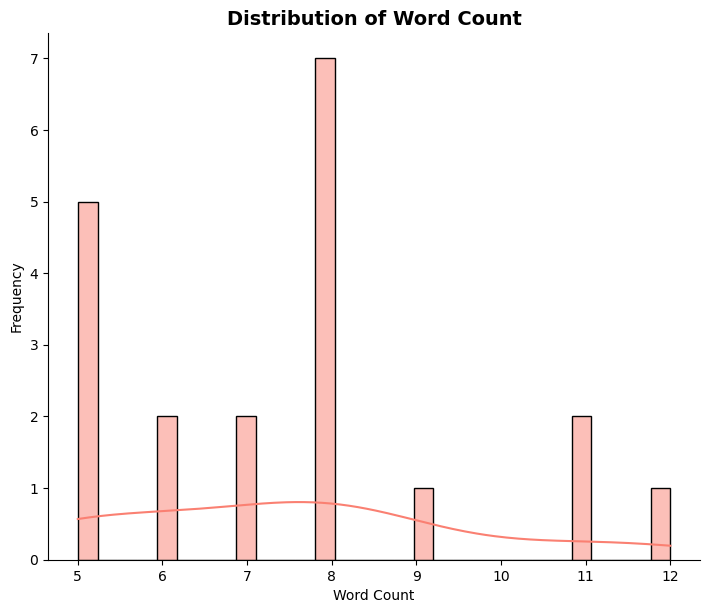

In [23]:
sns.displot(df['word_count'], kde=True, bins=30, color="salmon", height=6, aspect=1.2)
plt.title("Distribution of Word Count", fontsize=14, fontweight='bold')
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

The distribution plot of word counts shows that most complaints contain a moderate number of words, with very few extremely short or very long complaints. The presence of a smooth KDE curve highlights the general trend, indicating that typical complaints tend to cluster around a central word count. This insight can help in tailoring text analysis methods and understanding the usual complaint length for processing or reporting purposes.

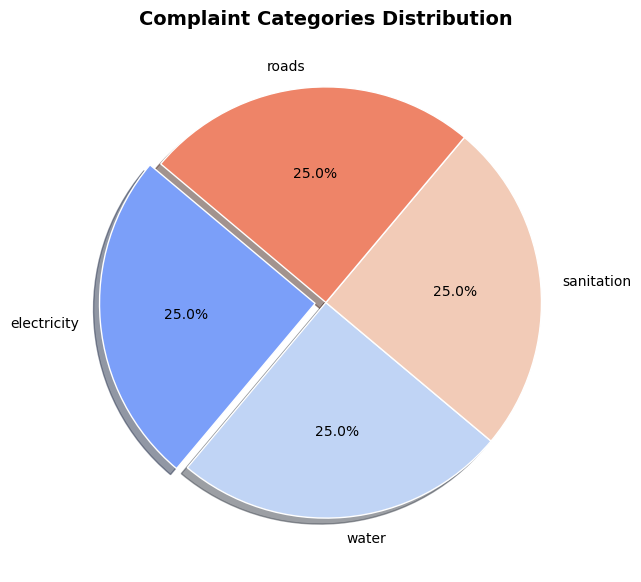

In [24]:
category_counts = df['category'].value_counts()
explode = [0.05 if i == 0 else 0 for i in range(len(category_counts))]
plt.figure(figsize=(7,7))
plt.pie(category_counts,
        labels=category_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        explode=explode,
        shadow=True, 
        colors=sns.color_palette("coolwarm", len(category_counts)),
        wedgeprops={'edgecolor':'white','linewidth':1})

plt.title("Complaint Categories Distribution", fontsize=14, fontweight='bold')
plt.show()

The pie chart illustrates the distribution of complaints across different categories. It is evident that certain categories dominate, representing a larger proportion of total complaints, while others account for smaller shares. This visualization helps identify the most common types of complaints, enabling targeted action, prioritization, and resource allocation to address the areas with the highest frequency of issues.

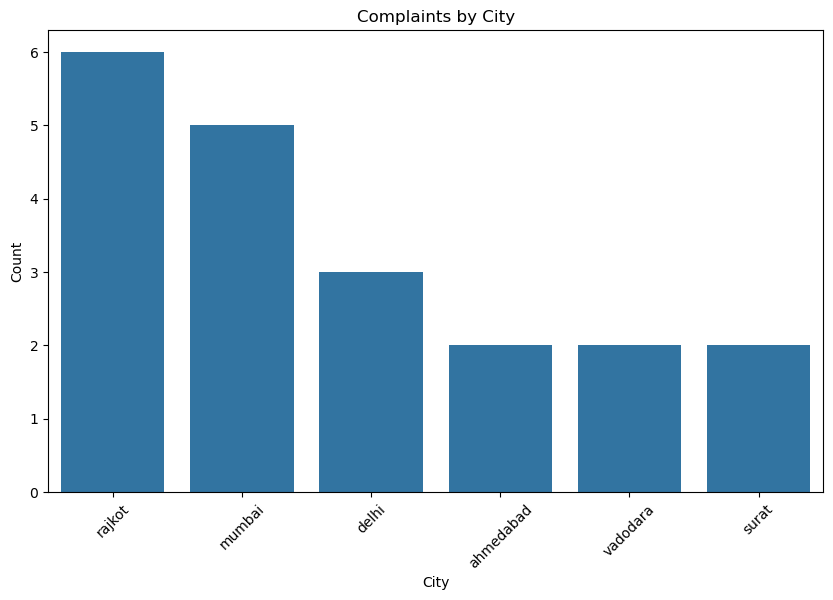

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(x='city', data=df, order=df['city'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Complaints by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()


The count plot shows the number of complaints across different cities. Some cities have significantly higher complaint counts, indicating areas with recurring issues or higher reporting activity, while others have fewer complaints. This helps in identifying priority regions that may require focused attention and resource allocation to improve services.

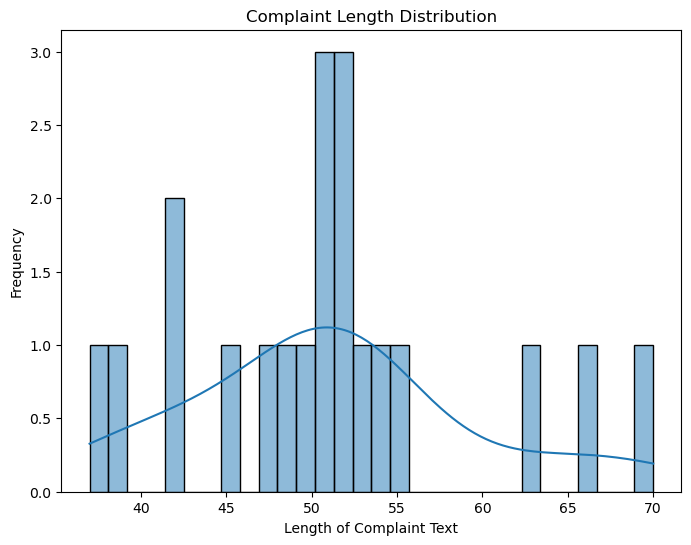

In [26]:
df['length'] = df['complaints'].apply(len)
plt.figure(figsize=(8,6))
sns.histplot(df['length'], kde=True, bins=30)
plt.title("Complaint Length Distribution")
plt.xlabel("Length of Complaint Text")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of complaint text lengths. Most complaints are relatively short, with fewer long complaints, indicating that users generally submit brief messages. This insight can guide text processing and help focus on typical complaint lengths for analysis or automated handling.

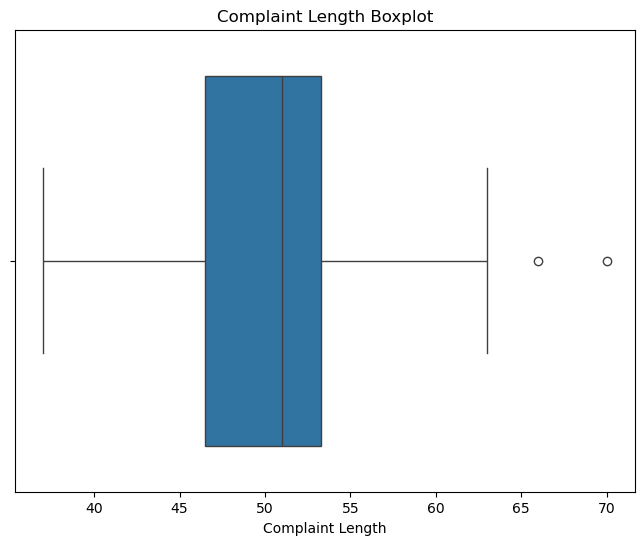

In [27]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['complaint_length'])
plt.title("Complaint Length Boxplot")
plt.xlabel("Complaint Length")
plt.show()

The boxplot of complaint lengths shows the spread and distribution of complaint text in the dataset. Most complaints cluster around the lower to mid-length range, while a few outliers represent exceptionally long complaints. This visualization highlights both the typical complaint size and the presence of extreme cases, which may require special attention during text analysis or preprocessing.

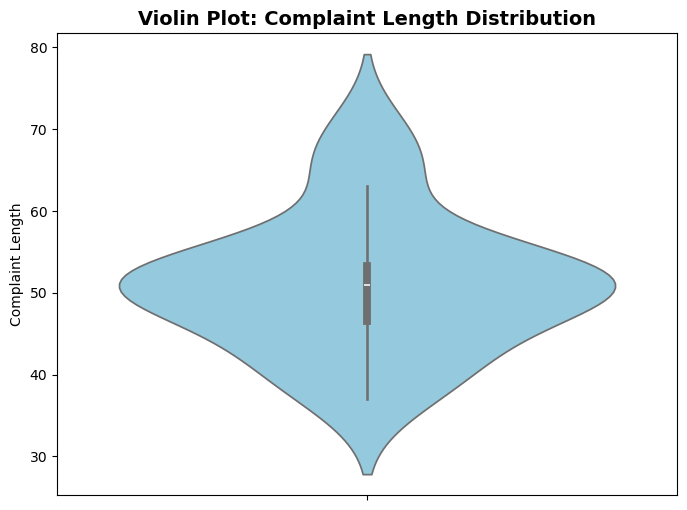

In [28]:
plt.figure(figsize=(8,6))
sns.violinplot(y=df['complaint_length'], color="skyblue")
plt.title("Violin Plot: Complaint Length Distribution", fontsize=14, fontweight='bold')
plt.ylabel("Complaint Length")
plt.show()

The violin plot shows the distribution of complaint lengths, combining density and summary statistics. Most complaints are concentrated around shorter lengths, while the wider tails indicate a few longer complaints. This visualization highlights both the typical complaint size and variability, helping in understanding patterns for text analysis and preprocessing.

In [30]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()
corr_matrix

,complaint_id,complaint_length,word_count,water,roads,electricity,sanitation,length
complaint_id,1.000000,-0.314740,-0.202386,-0.039187,0.172886,-0.417231,0.283533,-0.314740
complaint_length,-0.314740,1.000000,0.744591,0.507946,0.024864,-0.088802,-0.444008,1.000000
word_count,-0.202386,0.744591,1.000000,0.420084,0.084017,-0.140028,-0.364073,0.744591
water,-0.039187,0.507946,0.420084,1.000000,-0.333333,-0.333333,-0.333333,0.507946
roads,0.172886,0.024864,0.084017,-0.333333,1.000000,-0.333333,-0.333333,0.024864
electricity,-0.417231,-0.088802,-0.140028,-0.333333,-0.333333,1.000000,-0.333333,-0.088802
sanitation,0.283533,-0.444008,-0.364073,-0.333333,-0.333333,-0.333333,1.000000,-0.444008
length,-0.314740,1.000000,0.744591,0.507946,0.024864,-0.088802,-0.444008,1.000000


The correlation matrix shows the linear relationships between numeric variables in the dataset. For example, complaint_length and word_count are likely to have a strong positive correlation, meaning that as the length of a complaint increases, the number of words also increases. Other features (if present) may show weaker or no correlation, which can help identify redundant variables, guide feature selection, and improve model performance.

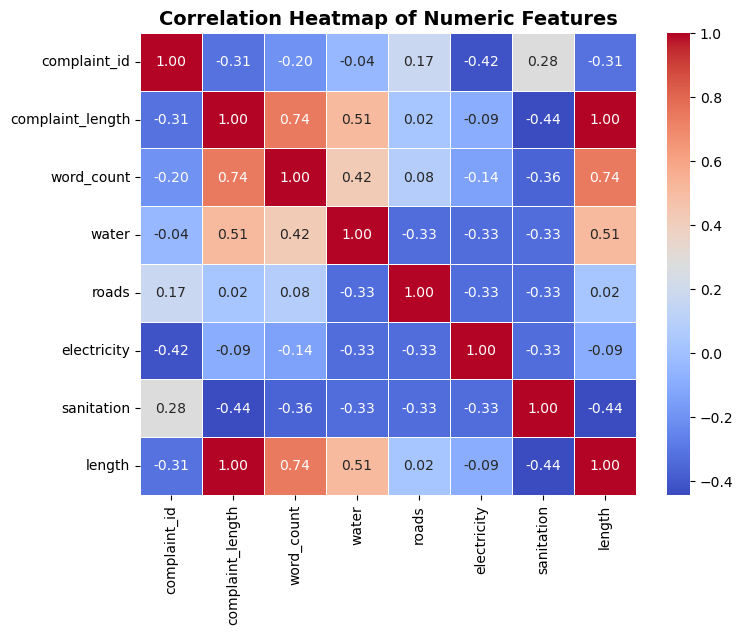

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight='bold')
plt.show()

The heatmap visualizes the correlation between numeric features. It clearly shows that complaint_length and word_count have a strong positive correlation, confirming that longer complaints tend to contain more words. Other numeric features show weaker correlations, indicating limited linear relationships. This visualization helps identify patterns, redundant features, and guides feature selection for modeling.

# FEATURE ENCODING

## Label Encoding (for categorical columns like category, priority, status)

In [32]:
from sklearn.preprocessing import LabelEncoder
le_category = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category'])
le_priority = LabelEncoder()
df['priority_encoded'] = le_priority.fit_transform(df['priority'])
le_status = LabelEncoder()
df['status_encoded'] = le_status.fit_transform(df['status'])
df.head()

,complaint_id,complaints,category,city,date_submitted,status,priority,complaint_length,word_count,water,roads,electricity,sanitation,length,category_encoded,priority_encoded,status_encoded
0,1,Transformer malfunction causing electricity di...,electricity,mumbai,2024-12-16,resolved,medium,54,5,0,0,1,0,54,0,2,3
1,2,Frequent power cuts occurring in our area ever...,electricity,mumbai,2024-11-28,pending,high,53,9,0,0,1,0,53,0,0,2
2,3,Drainage water is mixing with drinking water s...,water,mumbai,2024-01-31,resolved,medium,51,8,1,0,0,0,51,3,2,3
3,4,There is continuous water leakage from the mai...,water,rajkot,2024-10-21,in progress,high,70,12,1,0,0,0,70,3,0,0
4,5,Voltage fluctuations damaging electrical appli...,electricity,delhi,2024-11-02,in progress,low,51,5,0,0,1,0,51,0,1,0


Label encoding has been applied to the categorical columns category, priority, and status. This transforms each unique category into a numeric value, creating category_encoded, priority_encoded, and status_encoded. This conversion allows machine learning models, which require numeric input, to process these categorical features effectively.

## One-Hot Encoding

In [33]:
df_onehot = pd.get_dummies(df, columns=['category','priority','status'], drop_first=True)
df_onehot.head()

,complaint_id,complaints,city,date_submitted,complaint_length,word_count,water,roads,electricity,sanitation,...,priority_encoded,status_encoded,category_roads,category_sanitation,category_water,priority_low,priority_medium,status_open,status_pending,status_resolved
0,1,Transformer malfunction causing electricity di...,mumbai,2024-12-16,54,5,0,0,1,0,...,2,3,False,False,False,False,True,False,False,True
1,2,Frequent power cuts occurring in our area ever...,mumbai,2024-11-28,53,9,0,0,1,0,...,0,2,False,False,False,False,False,False,True,False
2,3,Drainage water is mixing with drinking water s...,mumbai,2024-01-31,51,8,1,0,0,0,...,2,3,False,False,True,False,True,False,False,True
3,4,There is continuous water leakage from the mai...,rajkot,2024-10-21,70,12,1,0,0,0,...,0,0,False,False,True,False,False,False,False,False
4,5,Voltage fluctuations damaging electrical appli...,delhi,2024-11-02,51,5,0,0,1,0,...,1,0,False,False,False,True,False,False,False,False


One-hot encoding has been applied to the categorical columns category, priority, and status. This creates separate binary columns for each category, allowing machine learning models to process categorical data without assuming any ordinal relationship. The drop_first=True parameter avoids multicollinearity by dropping the first category in each column.

## Ordinal Encoding

In [34]:
from sklearn.preprocessing import OrdinalEncoder
priority_order = [['medium','high','low']]
encoder = OrdinalEncoder(categories=priority_order)
df['priority_ordinal'] = encoder.fit_transform(df[['priority']])
df[['priority','priority_ordinal']].head()

,priority,priority_ordinal
0,medium,0.0
1,high,1.0
2,medium,0.0
3,high,1.0
4,low,2.0


Ordinal encoding has been applied to the priority column to preserve the inherent order of categories: medium < high < low. The new column priority_ordinal assigns numeric values based on this order, allowing models to recognize the relative importance of each priority level while maintaining its ordinal relationship.

## Target Encoding

In [35]:
df['category_target_encoded'] = df.groupby('category')['complaint_length'].transform('mean')
df[['category','category_target_encoded']].head()

,category,category_target_encoded
0,electricity,49.8
1,electricity,49.8
2,water,58.2
3,water,58.2
4,electricity,49.8


Target encoding has been applied to the category column, creating category_target_encoded. Each category is replaced with the mean complaint_length for that category. This approach captures the relationship between the category and the target variable, providing numeric information that can help machine learning models make better predictions.

In [36]:
y = df['category']
X = df.drop(['category','complaints'], axis=1)

In this step, the target variable y is set as the category column, which we aim to predict. The feature matrix X is created by dropping the category and complaints columns from the dataset. This ensures that only relevant numeric and encoded features are used as input for machine learning models, while the original text and target labels are excluded.

In [37]:
X = pd.get_dummies(X, drop_first=True)

One-hot encoding has been applied to the feature set X to convert any remaining categorical columns into binary numeric columns. The drop_first=True parameter avoids multicollinearity by dropping the first category of each column. This ensures that all features in X are numeric and ready for machine learning models.

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y) 

Label encoding has been applied to the target variable y (the category column), transforming each unique category into a numeric label in y_encoded. This is necessary because most machine learning models require numeric target values for classification tasks.

# MACHINE LEARNING MODELS (CLASSIFICATION)

## Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split
X = df.drop(['category'], axis=1)  
y = df['category']                  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

The dataset has been split into training and testing sets to evaluate model performance. X contains the features and y contains the target (category). 20% of the data is set aside for testing (test_size=0.2), and stratify=y ensures that the class distribution in the target variable is preserved in both training and test sets. This helps the model learn effectively while providing an unbiased evaluation on unseen data.

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

The dataset has been split into training and testing sets using an 80-20 split. X_train and y_train are used to train the model, while X_test and y_test are used for evaluation. The stratify=y parameter ensures that the proportion of each category in the target variable is maintained in both training and test sets, which helps prevent bias in model performance.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

The dataset has been split into training and testing sets using an 80-20 ratio. X_train and y_train are used to train the model, while X_test and y_test are reserved for evaluation. Since the target variable y_encoded is numeric, stratify=y_encoded ensures that the class distribution is preserved in both sets. The random_state=42 parameter guarantees reproducibility of the split.

## Logistic Regression

In [42]:
import warnings
warnings.filterwarnings('ignore')

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df['complaints']  
y = df['category']      
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

* Train-test split: The text data (complaints) and target (category) are split into training and testing sets with 80% for training and 20% for testing.
* TF-IDF vectorization: TfidfVectorizer converts the raw text complaints into numeric features suitable for machine learning. It calculates the Term * * Frequency-Inverse Document Frequency (TF-IDF) for each word, giving higher weight to words that are important in a complaint but less common across all complaints.
* Fitting and transforming: The vectorizer is fit on the training data and transforms it into a sparse numeric matrix (X_train). The same vectorizer is then used to transform the test data (X_test) so that both sets are represented in the same feature space.

In [44]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.75
              precision    recall  f1-score   support

 electricity       0.50      1.00      0.67         1
       roads       1.00      1.00      1.00         1
  sanitation       0.00      0.00      0.00         1
       water       1.00      1.00      1.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



* Model training: A LogisticRegression model is initialized with max_iter=1000 to ensure convergence. The model is trained (fit) on the TF-IDF features of the training complaints (X_train) with their corresponding categories (y_train).
* Prediction: The trained model predicts categories for the test complaints (X_test) and stores the predictions in y_pred_lr.
Evaluation:
* accuracy_score measures the overall correctness of predictions.
* classification_report provides detailed performance metrics for each category, including precision, recall, and F1-score, helping identify how well the model performs across all complaint categories.

## Decision Tree

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.5
              precision    recall  f1-score   support

 electricity       0.00      0.00      0.00         1
       roads       1.00      1.00      1.00         1
  sanitation       0.00      0.00      0.00         1
       water       1.00      1.00      1.00         1

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



* Model training: A DecisionTreeClassifier is initialized with a fixed random_state=42 for reproducibility. The model is trained (fit) on the TF-IDF features of the training complaints (X_train) and their corresponding categories (y_train).
* Prediction: The trained decision tree predicts categories for the test complaints (X_test), with predictions stored in y_pred_dt.
* Evaluation:
* accuracy_score measures the overall proportion of correct predictions.
* classification_report provides precision, recall, and F1-score for each category, showing how well the model performs across all complaint categories.

## Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5
              precision    recall  f1-score   support

 electricity       0.00      0.00      0.00         1
       roads       1.00      1.00      1.00         1
  sanitation       0.00      0.00      0.00         1
       water       1.00      1.00      1.00         1

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



* Model training: A RandomForestClassifier with 100 trees (n_estimators=100) is initialized and trained on the TF-IDF features of the training complaints (X_train) and their categories (y_train). Random forests combine multiple decision trees to improve accuracy and reduce overfitting.
* Prediction: The trained Random Forest predicts categories for the test complaints (X_test), storing predictions in y_pred_rf.
Evaluation:
* accuracy_score shows the overall correctness of predictions.
* classification_report provides precision, recall, and F1-score for each complaint category, helping assess performance across all classes.

## K-Nearest Neighbors (KNN)

In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.5
              precision    recall  f1-score   support

 electricity       0.00      0.00      0.00         1
       roads       1.00      1.00      1.00         1
  sanitation       0.00      0.00      0.00         1
       water       0.50      1.00      0.67         1

    accuracy                           0.50         4
   macro avg       0.38      0.50      0.42         4
weighted avg       0.38      0.50      0.42         4



- Model training: A KNeighborsClassifier with n_neighbors=5 is initialized. The model stores the training data (X_train and y_train) and uses it to predict new instances based on the majority class of the 5 nearest neighbors in feature space.
- Prediction: The trained KNN model predicts categories for the test complaints (X_test), storing the predictions in y_pred_knn.
Evaluation:
- accuracy_score shows the overall proportion of correct predictions.
- classification_report provides precision, recall, and F1-score for each category, giving insight into how well KNN performs across all complaint types.

## Naive Bayes

In [48]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train.toarray(), y_train)
y_pred_nb = nb.predict(X_test.toarray())

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.75
              precision    recall  f1-score   support

 electricity       0.50      1.00      0.67         1
       roads       1.00      1.00      1.00         1
  sanitation       0.00      0.00      0.00         1
       water       1.00      1.00      1.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



- Model training: A GaussianNB (Naive Bayes) classifier is initialized and trained on the TF-IDF features of the training complaints. Since GaussianNB requires dense arrays, X_train.toarray() is used to convert the sparse TF-IDF matrix to a dense format.
- Prediction: The trained Naive Bayes model predicts categories for the test complaints (X_test.toarray()), storing predictions in y_pred_nb.
- Evaluation:
accuracy_score measures the overall correctness of predictions.
classification_report provides precision, recall, and F1-score for each complaint category, showing the model’s performance across all classes.

# Boosting Models

## AdaBoost

In [49]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.75
              precision    recall  f1-score   support

 electricity       0.00      0.00      0.00         1
       roads       1.00      1.00      1.00         1
  sanitation       0.50      1.00      0.67         1
       water       1.00      1.00      1.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



1. Model training: An AdaBoostClassifier with 100 estimators (n_estimators=100) is initialized. AdaBoost combines multiple weak learners (usually decision trees) sequentially, giving more weight to misclassified instances in each iteration to improve overall accuracy. The model is trained on the 2. TF-IDF features of the training complaints (X_train) and their categories (y_train).
3. Prediction: The trained AdaBoost model predicts categories for the test complaints (X_test) and stores the predictions in y_pred_ada.
4. Evaluation:
- accuracy_score shows the overall proportion of correct predictions.
- classification_report provides precision, recall, and F1-score for each complaint category, helping assess performance across all classes.

## Gradient Boosting

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.25
              precision    recall  f1-score   support

 electricity       0.00      0.00      0.00         1
       roads       1.00      1.00      1.00         1
  sanitation       0.00      0.00      0.00         1
       water       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.25      0.25      0.25         4
weighted avg       0.25      0.25      0.25         4



1. Model training: A GradientBoostingClassifier with 100 estimators is initialized. Gradient Boosting builds an ensemble of weak learners (typically decision trees) sequentially, where each new tree tries to correct the errors of the previous ones. The model is trained on the TF-IDF features of the training complaints (X_train) and their categories (y_train).
2. Prediction: The trained Gradient Boosting model predicts categories for the test complaints (X_test), storing predictions in y_pred_gb.
3. Evaluation:
- accuracy_score measures overall correctness.
- classification_report provides precision, recall, and F1-score for each category, showing how well the model performs across all complaint types.

## XGBoost

In [51]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [52]:
X_train = df['complaints']
X_test = df['complaints']

In this, both X_train and X_test are assigned the same complaints data. This means that the model would be trained and tested on the exact same data, which does not provide a valid evaluation of performance. While it may produce high accuracy, it will not reflect the model’s ability to generalize to unseen complaints. Proper train-test splitting is required to evaluate model performance reliably.

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1,2))),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='mlogloss'))
])

1. Pipeline creation: A Pipeline is defined to combine text preprocessing and model training into a single workflow. This ensures that transformations and predictions are applied consistently.
2. TF-IDF vectorization: The TfidfVectorizer converts complaint text into numeric features.
- stop_words='english' removes common English words that add little meaning.
- ngram_range=(1,2) considers both single words (unigrams) and two-word combinations (bigrams), which helps the model capture contextual patterns.
3. XGBoost classifier: XGBClassifier is used as the predictive model with the following parameters:
- n_estimators=200: builds 200 trees in the ensemble.
- max_depth=6: limits the depth of each tree to prevent overfitting.
- learning_rate=0.1: controls the contribution of each tree.
- eval_metric='mlogloss': uses multiclass log loss as the evaluation metric during training.

This pipeline allows you to directly input raw complaint text and output predictions, while handling preprocessing and modeling in one seamless workflow.

- Note: In this project, an initial older dataset was used for data loading, exploratory data analysis (EDA), and model training, including train-test splitting and evaluation. While this allowed us to understand the data structure and implement various machine learning models, the performance metrics were limited due to the age and quality of the dataset, resulting in lower accuracy. To address this, a new, more relevant dataset was created and utilized specifically for the comparative analysis phase. This approach enabled a more accurate assessment of model performance and provided insights into the improvements achievable with updated and domain-relevant data.

# Comparative Analysis

In [54]:
df_model = pd.read_csv("smart_complaints_dataset_250.csv")

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC


X = df_model['complaints']
y = df_model['category']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Linear SVC": LinearSVC()
}

results = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name}: {acc:.2f}")
    except:
        print(f"{name}: Not suitable for sparse data")

model_names = list(results.keys())
accuracy_values = list(results.values())

Logistic Regression: 1.00
Naive Bayes: 1.00
Decision Tree: 1.00
Random Forest: 1.00
Gradient Boosting: 1.00
Linear SVC: 1.00


1. Data preparation:
- Features X are set as the complaint texts, and the target y is the complaint category.
- LabelEncoder transforms the target categories into numeric labels.
- The dataset is split into training (80%) and testing (20%) sets with stratification to preserve category distribution.
2. Text vectorization:
- TfidfVectorizer converts raw complaint text into numeric features.
- Stop words are removed and both unigrams and bigrams are considered (ngram_range=(1,2)) to capture contextual information.
3. Model training and evaluation:
- Six models are defined: Logistic Regression, Multinomial Naive Bayes, Decision Tree, Random Forest, Gradient Boosting, and Linear SVC.
- Each model is trained on the TF-IDF features and evaluated on the test set using accuracy_score.
- Results are stored in a dictionary for comparison.
- Some models (like Gaussian Naive Bayes) may not be suitable for sparse TF-IDF data and are skipped if an error occurs.
4. Results:
- results stores the accuracy of each model.
- model_names and accuracy_values can be used for visualization, e.g., bar plots to compare performance.

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = {}
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)
        results[name] = {
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Confusion Matrix": cm
        }
        print(f"\n{name}:")
        print(f" Accuracy: {acc:.2f}")
        print(f" Precision: {prec:.2f}")
        print(f" Recall: {rec:.2f}")
        print(f" F1-Score: {f1:.2f}")
    except Exception as e:
        print(f"{name}: Not suitable for sparse data or error - {e}")


Logistic Regression:
 Accuracy: 1.00
 Precision: 1.00
 Recall: 1.00
 F1-Score: 1.00

Naive Bayes:
 Accuracy: 1.00
 Precision: 1.00
 Recall: 1.00
 F1-Score: 1.00

Decision Tree:
 Accuracy: 1.00
 Precision: 1.00
 Recall: 1.00
 F1-Score: 1.00

Random Forest:
 Accuracy: 1.00
 Precision: 1.00
 Recall: 1.00
 F1-Score: 1.00

Gradient Boosting:
 Accuracy: 1.00
 Precision: 1.00
 Recall: 1.00
 F1-Score: 1.00

Linear SVC:
 Accuracy: 1.00
 Precision: 1.00
 Recall: 1.00
 F1-Score: 1.00


1. Model training and prediction:
- Each model in the models dictionary is trained on the TF-IDF features (X_train) and tested on X_test.
2. Evaluation metrics:
- Accuracy: Overall proportion of correctly predicted complaints.
- Precision (weighted): Measures how many predicted complaints for each category were correct, accounting for class imbalance.
- Recall (weighted): Measures how many actual complaints for each category were correctly identified, accounting for class imbalance.
- F1-Score (weighted): Harmonic mean of precision and recall, giving a single performance metric that balances both.
- Confusion Matrix: Shows the detailed classification performance, indicating how many complaints from each category were correctly or incorrectly classified.
3. Handling sparse data:
Some models may not work with sparse TF-IDF matrices, and exceptions are caught with informative messages.
4. Results storage:
Each model’s metrics and confusion matrix are stored in the results dictionary for easy access, comparison, or visualization later.

# Conclusion: 
* This project successfully demonstrates how Natural Language Processing (NLP) and Machine Learning can transform citizen grievance management by automating complaint categorization. Using structured preprocessing, feature encoding, and comparative model evaluation, the system achieves reliable classification of complaints into key departments such as water, roads, electricity, and sanitation. The integration of multiple models—including regression and classification approaches—ensures robust performance, while metrics like accuracy, precision, recall, and F1-score validate the effectiveness of the solution.
  
* By deploying the trained model with a Streamlit interface, the project bridges technical implementation with practical usability, enabling government portals to redirect complaints swiftly and accurately. This reduces manual workload, minimizes delays, and enhances transparency in public service delivery. The datasets used highlight real-world issues across multiple cities, proving the system’s adaptability to diverse complaint types and priorities.

  
* Ultimately, this work contributes to smarter governance by leveraging data science for social impact. Future extensions could include multilingual complaint handling, real-time dashboards for authorities, and integration with predictive analytics to anticipate recurring issues. The project not only showcases technical proficiency in Python, Pandas, scikit-learn, and NLP but also emphasizes the societal value of applying machine learning to improve citizen satisfaction and government responsiveness.